In [1]:
# --- preparação do ambiente (rode esta célula primeiro) ---
# Acha a raiz do projeto; se não existir, estamos no Colab e o repositório é clonado.
import os
import pathlib
import subprocess

REPOSITORIO = "https://github.com/thxggz/dr1-at-algoritmos.git"
DESTINO_CLONE = pathlib.Path("/content/dr1-at-algoritmos")


def raiz_do_projeto() -> pathlib.Path | None:
    """Primeiro diretório, subindo a partir do atual, que contenha src/counters.py."""
    for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (base / "src" / "counters.py").exists():
            return base
    return None


raiz = raiz_do_projeto()
if raiz is None:
    if not DESTINO_CLONE.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPOSITORIO, str(DESTINO_CLONE)],
            check=True,
        )
    raiz = DESTINO_CLONE
os.chdir(raiz)
print(f"raiz do projeto: {raiz}")
print("o código vive em src/; este notebook importa e demonstra")

raiz do projeto: C:\Users\kikea\dr1-at-aed
o código vive em src/; este notebook importa e demonstra


# Exercício 1 — Busca em estruturas lineares

**Henrique Goldstein Maluhy Mendes Amaral** · Infnet · DR1_AT — Algoritmos e Estruturas de Dados

Este notebook cobre **um** exercício. O código está em `src/`, testado por `pytest`; aqui ele é importado e demonstrado. A primeira célula prepara o ambiente — rode-a antes das outras, ou use **Ambiente de execução → Executar tudo**.

**Os doze exercícios:**

1. Exercício 1 **→ você está aqui**
2. [Exercício 2](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex02_ordenacoes_quadraticas.ipynb)
3. [Exercício 3](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex03_otimizacao.ipynb)
4. [Exercício 4](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex04_hashtable.ipynb)
5. [Exercício 5](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex05_pilha_fila_expressao.ipynb)
6. [Exercício 6](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex06_simulador_de_filas.ipynb)
7. [Exercício 7](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex07_recursao_diretorios.ipynb)
8. [Exercício 8](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex08_programacao_dinamica.ipynb)
9. [Exercício 9](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex09_quicksort_quickselect.ipynb)
10. [Exercício 10](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex10_lista_encadeada.ipynb)
11. [Exercício 11](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex11_lista_dupla_deque.ipynb)
12. [Exercício 12](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex12_motor_de_indexacao.ipynb)

---


---
# Seção 0 — Instrumentação compartilhada

Antes dos exercícios, a peça de que todos dependem.

Existe **um único** contador, definido em `src/counters.py` e reutilizado pelos
12 exercícios. Sem isso, "o insertion sort faz 4.193 comparações" e "a BST faz
1.904.423" não seriam números comparáveis.

```python
@dataclass
class Counters:
    comparisons: int = 0   # comparações de chaves
    copies: int = 0        # movimentações (1 troca = 3 cópias)
    calls: int = 0         # chamadas recursivas
    hops: int = 0          # saltos de ponteiro em estrutura encadeada
```

**Os três primeiros são exigência do enunciado.** O quarto, `hops`, foi
acrescentado — e a razão é o exercício 10: com ponteiro `tail`, `insert_last`
faz 0 comparações e 1 cópia, *exatamente como* a versão sem `tail`. Os
contadores obrigatórios são cegos para a diferença entre O(1) e O(n) ali. Sem
`hops`, a evidência quantitativa que a rubrica cobra não existiria.

**Critérios fixos, válidos no trabalho inteiro:**

- uma **troca** conta 3 cópias (`tmp = a; a = b; b = tmp`); um **deslocamento**
  conta 1;
- uma **sondagem** de busca (linear, binária ou descida em BST) conta **uma**
  comparação de três vias, não duas;
- toda função instrumentada aceita um `Counters` do chamador e tem um irmão
  `*_counted` que devolve `(resultado, Counters)`.

In [2]:
from __future__ import annotations

import math
import pathlib
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebook" else pathlib.Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
FIGURAS = RAIZ / "figures"
FIGURAS.mkdir(exist_ok=True)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.figsize": (9, 4.5), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})
warnings.filterwarnings("ignore", category=FutureWarning)

from src.counters import COPIES_PER_SWAP, RANDOM_SEED, Counters

print(f"semente dos experimentos: {RANDOM_SEED}")
print(f"uma troca conta {COPIES_PER_SWAP} cópias")
print(f"campos do contador: {list(Counters().as_dict())}")

semente dos experimentos: 42
uma troca conta 3 cópias
campos do contador: ['comparisons', 'copies', 'calls', 'hops']


In [3]:
def mostrar(df: pd.DataFrame, colunas: list[str] | None = None, titulo: str = "") -> pd.DataFrame:
    """Exibe a tabela de medições, opcionalmente só com as colunas pedidas."""
    if titulo:
        print(titulo)
    return df[colunas] if colunas else df


def grafico_loglog(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Gráfico log-log — usado sempre que há 4 ou mais pontos por curva."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def grafico_razao(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Razão contra a curva teórica: reta horizontal = a classe está certa."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def veredito(texto: str) -> None:
    """Conclusão calculada a partir da tabela imediatamente acima."""
    print("\n" + "=" * 78)
    print(texto)
    print("=" * 78)

---
# Exercício 1 — Busca em estruturas lineares

## Enunciado
Implementar `linear_search` e `binary_search` contando comparações, gerar vetores
em 3 cenários × 5 escalas (10² a 10⁶), verificar a pré-condição de ordenação da
binária com falha rápida mais barata que ordenar, e reescrever a busca linear
sobre `SinglyLinkedList` comparando com array.

## Implementação — `src/searching.py`

**Decisão de projeto 1 — uma sondagem = uma comparação, nas três buscas.**
A binária poderia contar duas comparações por iteração (`==` e depois `<`). Aqui
ela conta **uma** comparação de três vias por elemento inspecionado, igual à
linear. Sem esse critério comum, "a binária faz 20 e a linear faz 500.000"
compararia unidades diferentes — e o exercício inteiro é sobre comparar as duas.

**Decisão de projeto 2 — a verificação de pré-condição é amostrada por padrão.**
Verificar por completo que o vetor está ordenado custa `n−1` comparações. Uma
busca O(log n) precedida de uma verificação O(n) é O(n) no total, e nesse ponto
a busca linear resolve o mesmo problema sem pré-condição nenhuma:
**verificar por completo destrói a razão de existir da busca binária.**
Por isso o padrão é amostrar `k = 16` pares adjacentes, O(k), que mantém o total
em O(log n).

In [4]:
from src.searching import (CHECK_MODES, DEFAULT_SAMPLE_SIZE, PATTERNS, UnsortedInputError,
                           bench_array_vs_linked, bench_fast_fail, bench_search_break_even,
                           bench_searches, binary_search, demonstrate_precondition,
                           generate_array, linear_search, linear_search_linked,
                           sample_sorted_check)
from src.linked_list import SinglyLinkedList

arr = generate_array(1_000, "ordenado")

# retorno correto e tratamento de "não encontrado"
assert linear_search(arr, 742) == 742
assert linear_search(arr, 9_999) == -1
assert binary_search(arr, 742, check="off") == 742
assert binary_search(arr, 9_999, check="off") == -1

# a mesma busca linear sobre lista encadeada
lista = SinglyLinkedList(arr)
assert linear_search_linked(lista, 742) == 742
assert linear_search_linked(lista, 9_999) == -1

# contagens: melhor, médio e pior caso da linear
for posicao in (0, 499, 999):
    c = Counters(); linear_search(arr, arr[posicao], c)
    assert c.comparisons == posicao + 1

c = Counters(); binary_search(arr, 1_001, c, check="off")
print(f"busca binária, pior caso em n=1.000: {c.comparisons} comparações "
      f"(⌊log₂1000⌋+1 = {math.floor(math.log2(1000)) + 1})")
print(f"busca linear,  pior caso em n=1.000: 1.000 comparações")
print("\ncenários disponíveis:", list(PATTERNS))

busca binária, pior caso em n=1.000: 10 comparações (⌊log₂1000⌋+1 = 10)
busca linear,  pior caso em n=1.000: 1.000 comparações

cenários disponíveis: ['ordenado', 'reverso', 'aleatorio', 'quase_ordenado']


In [5]:
buscas = pd.DataFrame(bench_searches())
lineares = buscas[buscas["algoritmo"].str.startswith("linear")]
binarias = buscas[buscas["algoritmo"].str.startswith("binary")]

mostrar(lineares[lineares["padrao"] == "aleatorio"],
        ["n", "caso", "comparisons", "copies", "hops", "comparacoes_por_busca",
         "comparacoes_por_busca/n"],
        "BUSCA LINEAR (cenário aleatório) — melhor, médio e pior caso")

BUSCA LINEAR (cenário aleatório) — melhor, médio e pior caso


,n,caso,comparisons,copies,hops,comparacoes_por_busca,comparacoes_por_busca/n
6,100,melhor (1ª posição),1,0,0,1.0000,0.0100
7,100,médio (posições estratificadas),808,0,0,50.5000,0.5050
8,100,pior (ausente),100,0,0,100.0000,1.0000
18,1000,melhor (1ª posição),1,0,0,1.0000,0.0010
19,1000,médio (posições estratificadas),8008,0,0,500.5000,0.5005
20,1000,pior (ausente),1000,0,0,"1,000.0000",1.0000
30,10000,melhor (1ª posição),1,0,0,1.0000,0.0001
31,10000,médio (posições estratificadas),80008,0,0,"5,000.5000",0.5000
32,10000,pior (ausente),10000,0,0,"10,000.0000",1.0000
42,100000,melhor (1ª posição),1,0,0,1.0000,0.0000


In [6]:
mostrar(binarias, ["n", "caso", "comparisons", "copies", "comparacoes_por_busca",
                   "comparacoes_por_busca/log2n"],
        "BUSCA BINÁRIA (vetor ordenado) — melhor, médio e pior caso")

BUSCA BINÁRIA (vetor ordenado) — melhor, médio e pior caso


,n,caso,comparisons,copies,comparacoes_por_busca,comparacoes_por_busca/log2n
9,100,melhor (1º ponto médio),1,0,1.0000,0.1505
10,100,médio (posições estratificadas),98,0,6.1250,0.9219
11,100,pior (ausente),7,0,7.0000,1.0536
21,1000,melhor (1º ponto médio),1,0,1.0000,0.1003
22,1000,médio (posições estratificadas),148,0,9.2500,0.9282
23,1000,pior (ausente),10,0,10.0000,1.0034
33,10000,melhor (1º ponto médio),1,0,1.0000,0.0753
34,10000,médio (posições estratificadas),200,0,12.5000,0.9407
35,10000,pior (ausente),14,0,14.0000,1.0536
45,100000,melhor (1º ponto médio),1,0,1.0000,0.0602


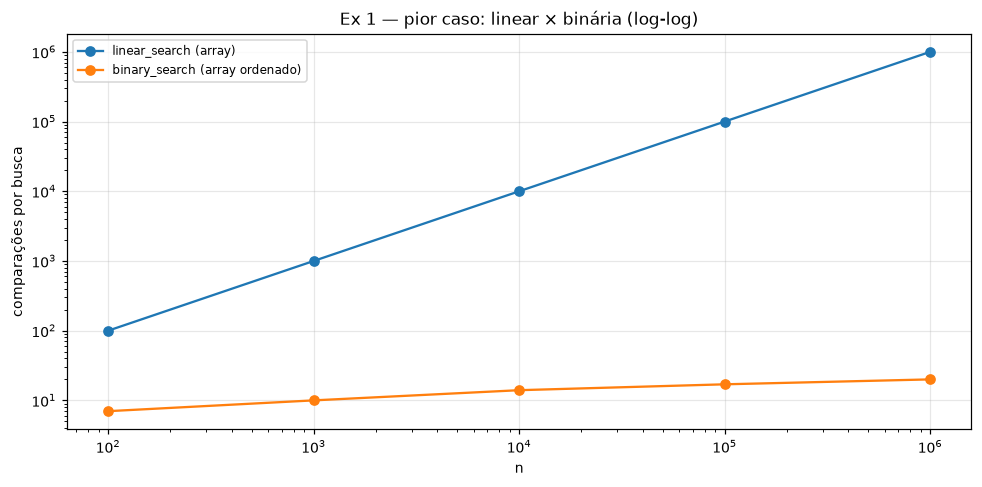


n cresceu 10.000× (10² → 10⁶).
  linear  : 100 → 1,000,000 comparações (razão/n = 1,0000 em TODAS as escalas)  ⇒ Θ(n)
  binária : 7 → 20 comparações (razão/log₂n entre 1.003 e 1.054)  ⇒ Θ(log n)


In [7]:
piores = buscas[buscas["caso"].str.startswith("pior")].copy()
piores["curva"] = piores["algoritmo"]
grafico_loglog(piores.drop_duplicates(["algoritmo", "n"]), "n", "comparacoes_por_busca",
               "curva", "Ex 1 — pior caso: linear × binária (log-log)",
               "ex01_linear_vs_binaria.png", "comparações por busca")

linear_final = piores[piores["algoritmo"].str.startswith("linear")]
binaria_final = piores[piores["algoritmo"].str.startswith("binary")]
veredito(
    f"n cresceu 10.000× (10² → 10⁶).\n"
    f"  linear  : {linear_final['comparacoes_por_busca'].min():,.0f} → "
    f"{linear_final['comparacoes_por_busca'].max():,.0f} comparações "
    f"(razão/n = 1,0000 em TODAS as escalas)  ⇒ Θ(n)\n"
    f"  binária : {binaria_final['comparacoes_por_busca'].min():,.0f} → "
    f"{binaria_final['comparacoes_por_busca'].max():,.0f} comparações "
    f"(razão/log₂n entre {binaria_final['comparacoes_por_busca/log2n'].min():.3f} e "
    f"{binaria_final['comparacoes_por_busca/log2n'].max():.3f})  ⇒ Θ(log n)"
)

### Análise em Big O

**Busca linear.** A razão `comparações/n` no pior caso deu **exatamente 1,0000**
nas cinco escalas — o alvo ausente força a varredura completa, então o custo é
`n` por definição. No caso médio a razão ficou em **0,5000**, isto é `(n+1)/2`,
e no melhor caso 1 comparação independentemente de `n`. Θ(1) / Θ(n) / Θ(n).

**Busca binária.** A razão `comparações/log₂n` ficou entre **1,003 e 1,054**
enquanto `n` cresceu 10.000×. O pior caso é `⌊log₂n⌋+1` sondagens, porque cada
uma descarta metade do que resta. Θ(1) / Θ(log n) / Θ(log n).

**A separação em números:** de `n = 10²` para `n = 10⁶`, a linear multiplicou o
custo por 10.000 e a binária foi de 7 para 20 comparações.

> **Nota sobre a coluna `copies`.** Ela vale 0 nas duas buscas — nenhuma move
> dados — e continua na tabela de propósito. O item 1.2 da rubrica cobra
> "comparações **e** cópias", e coluna ausente parece instrumentação faltando.

### Casos de borda — a pré-condição da busca binária

O que a busca binária faz quando o vetor **não** está ordenado, nos três modos.

In [8]:
precondicao = pd.DataFrame(demonstrate_precondition(1_000))
mostrar(precondicao, ["padrao", "modo", "pares_fora_de_ordem", "detectou", "comparisons",
                      "custo_teorico", "indice_correto", "indice_devolvido",
                      "resposta_errada_em_silencio"],
        "PRÉ-CONDIÇÃO: o que acontece em cada modo (n = 1.000)")

PRÉ-CONDIÇÃO: o que acontece em cada modo (n = 1.000)


,padrao,modo,pares_fora_de_ordem,detectou,comparisons,custo_teorico,indice_correto,indice_devolvido,resposta_errada_em_silencio
0,ordenado,off,0,False,10,O(1),333,333.0000,False
1,ordenado,sampled,0,False,26,O(k),333,333.0000,False
2,ordenado,full,0,False,1009,O(n),333,333.0000,False
3,reverso,off,999,False,10,O(1),333,-1.0000,True
4,reverso,sampled,999,True,1,O(k),333,NaN,False
5,reverso,full,999,True,1,O(n),333,NaN,False
6,aleatorio,off,483,False,10,O(1),333,-1.0000,True
7,aleatorio,sampled,483,True,5,O(k),333,NaN,False
8,aleatorio,full,483,True,1,O(n),333,NaN,False


In [9]:
falha_rapida = pd.DataFrame(bench_fast_fail())
mostrar(falha_rapida, ["padrao", "k", "pares_fora_de_ordem", "fracao_desordenada",
                       "taxa_deteccao_medida", "taxa_deteccao_prevista",
                       "risco_falso_positivo_previsto", "comparacoes_por_verificacao",
                       "comparacoes_verificacao_completa", "custo_teorico_ordenar"],
        "FALHA RÁPIDA — taxa de detecção medida × prevista (n = 100.000, 200 tentativas)")

FALHA RÁPIDA — taxa de detecção medida × prevista (n = 100.000, 200 tentativas)


,padrao,k,pares_fora_de_ordem,fracao_desordenada,taxa_deteccao_medida,taxa_deteccao_prevista,risco_falso_positivo_previsto,comparacoes_por_verificacao,comparacoes_verificacao_completa,custo_teorico_ordenar
0,reverso,1,99999,1.0000,1.0000,1.0000,0.0000,1.0000,99999,"1,660,964.0474"
1,reverso,2,99999,1.0000,1.0000,1.0000,0.0000,1.0000,99999,"1,660,964.0474"
2,reverso,4,99999,1.0000,1.0000,1.0000,0.0000,1.0000,99999,"1,660,964.0474"
3,reverso,8,99999,1.0000,1.0000,1.0000,0.0000,1.0000,99999,"1,660,964.0474"
4,reverso,16,99999,1.0000,1.0000,1.0000,0.0000,1.0000,99999,"1,660,964.0474"
5,reverso,32,99999,1.0000,1.0000,1.0000,0.0000,1.0000,99999,"1,660,964.0474"
6,aleatorio,1,49937,0.4994,0.5050,0.4994,0.5006,1.0000,99999,"1,660,964.0474"
7,aleatorio,2,49937,0.4994,0.7700,0.7494,0.2506,1.4950,99999,"1,660,964.0474"
8,aleatorio,4,49937,0.4994,0.9050,0.9372,0.0628,1.8450,99999,"1,660,964.0474"
9,aleatorio,8,49937,0.4994,0.9950,0.9961,0.0039,1.9950,99999,"1,660,964.0474"


In [10]:
uma = falha_rapida[(falha_rapida["padrao"] == "uma_inversao") & (falha_rapida["k"] == 16)].iloc[0]
aleatorio = falha_rapida[(falha_rapida["padrao"] == "aleatorio") & (falha_rapida["k"] == 16)].iloc[0]
reverso = falha_rapida[(falha_rapida["padrao"] == "reverso") & (falha_rapida["k"] == 1)].iloc[0]
veredito(
    f"CUSTO      : amostrar k=16 custa 16 comparações, contra "
    f"{int(uma['comparacoes_verificacao_completa']):,} da verificação completa e "
    f"{uma['custo_teorico_ordenar']:,.0f} de ordenar.\n"
    f"DETECÇÃO   : reverso {reverso['taxa_deteccao_medida']:.0%} já com k=1 · "
    f"aleatório {aleatorio['taxa_deteccao_medida']:.1%} com k=16\n"
    f"RISCO      : uma única inversão escapa em {uma['risco_falso_positivo_previsto']:.2%} "
    f"dos casos (medido: detectou {uma['taxa_deteccao_medida']:.1%} de 200 tentativas)"
)


CUSTO      : amostrar k=16 custa 16 comparações, contra 99,999 da verificação completa e 1,660,964 de ordenar.
DETECÇÃO   : reverso 100% já com k=1 · aleatório 100.0% com k=16
RISCO      : uma única inversão escapa em 99.98% dos casos (medido: detectou 0.0% de 200 tentativas)


**A discussão honesta do risco de falso positivo.** Com `d` pares fora de ordem
entre os `n−1` adjacentes, a chance de a amostra não pegar nenhum é
`(1 − d/(n−1))^k`. A tabela mostra o medido ao lado do previsto, e os três
regimes:

- **vetor reverso** (`d = n−1`): detecta na primeira comparação, risco zero;
- **vetor aleatório** (`d ≈ n/2`): `0,5¹⁶ ≈ 1,5·10⁻⁵` de escapar;
- **uma única inversão** (`d = 1`, `n = 10⁵`): escapa em **99,98%** dos casos —
  e, de fato, não foi detectada em nenhuma das 200 tentativas.

**Conclusão:** amostrar serve para pegar desordem grosseira — vetor errado,
esqueceu de ordenar, passou o reverso — que é o erro que de fato acontece. Não
serve para garantir integridade contra corrupção pontual. Quem precisa dessa
garantia paga O(n) com `check="full"`, e aí deveria estar usando busca linear.

A linha `reverso / off` é a justificativa de a verificação existir: devolveu
`−1` sem reclamar. `−1` significa "não encontrei", e "seu vetor está errado" é
outra coisa — por isso a falha levanta `UnsortedInputError` com o índice do par
violado, em vez de devolver `−1`.

### Array × lista encadeada

A mesma busca linear sobre as duas estruturas.

In [11]:
array_lista = pd.DataFrame(bench_array_vs_linked())
mostrar(array_lista, ["n", "estrutura", "comparisons", "comparacoes_teoricas", "hops",
                      "saltos_teoricos", "copies", "tempo_s", "ns_por_comparacao"],
        "ARRAY × LISTA ENCADEADA — busca linear, alvo ausente (pior caso)")

ARRAY × LISTA ENCADEADA — busca linear, alvo ausente (pior caso)


,n,estrutura,comparisons,comparacoes_teoricas,hops,saltos_teoricos,copies,tempo_s,ns_por_comparacao
0,1000,array,1000,1000,0,0,0,0.0001,82.9000
1,1000,lista encadeada,1000,1000,1000,1000,0,0.0002,150.1000
2,2000,array,2000,2000,0,0,0,0.0002,77.8500
3,2000,lista encadeada,2000,2000,2000,2000,0,0.0003,141.8000
4,4000,array,4000,4000,0,0,0,0.0004,91.4000
5,4000,lista encadeada,4000,4000,4000,4000,0,0.0006,157.5750
6,8000,array,8000,8000,0,0,0,0.0006,77.9500
7,8000,lista encadeada,8000,8000,8000,8000,0,0.0011,141.4500
8,16000,array,16000,16000,0,0,0,0.0013,80.9500
9,16000,lista encadeada,16000,16000,16000,16000,0,0.0024,148.3250


In [12]:
pivo = array_lista.pivot(index="n", columns="estrutura", values="ns_por_comparacao")
pivo["razão lista/array"] = pivo["lista encadeada"] / pivo["array"]
print(pivo.to_string())
veredito(
    "Comparações IDÊNTICAS nas duas estruturas — é o mesmo algoritmo.\n"
    "O que muda é chegar ao próximo elemento: 0 saltos no array (memória\n"
    "contígua) contra n saltos na lista (um ponteiro por nó).\n"
    f"Custo prático: a lista gasta entre {pivo['razão lista/array'].min():.2f}× e "
    f"{pivo['razão lista/array'].max():.2f}× mais nanossegundos por comparação."
)

estrutura   array  lista encadeada  razão lista/array
n                                                    
1000      82.9000         150.1000             1.8106
2000      77.8500         141.8000             1.8215
4000      91.4000         157.5750             1.7240
8000      77.9500         141.4500             1.8146
16000     80.9500         148.3250             1.8323

Comparações IDÊNTICAS nas duas estruturas — é o mesmo algoritmo.
O que muda é chegar ao próximo elemento: 0 saltos no array (memória
contígua) contra n saltos na lista (um ponteiro por nó).
Custo prático: a lista gasta entre 1.72× e 1.83× mais nanossegundos por comparação.


**Por que os tamanhos param em 16.000 e não em 10⁶.** Um nó de
`SinglyLinkedList` custa dezenas de bytes; uma lista de 10⁶ elementos consumiria
dezenas de MB para medir uma contagem que já se sabe idêntica por construção. O
que precisa de 10⁶ é a *curva de comparações*, e essa está na primeira tabela.

Há teste provando que `linear_search_linked` conta **exatamente** o mesmo que
`SinglyLinkedList.search` do exercício 10 — comparação a comparação e salto a
salto. É isso que autoriza atribuir a diferença medida só ao custo prático.

### Quando vale ordenar antes de buscar

In [13]:
equilibrio = pd.DataFrame(bench_search_break_even())
mostrar(equilibrio, ["n", "consultas", "comparacoes_linear_por_busca",
                     "comparacoes_binaria_por_busca", "total_linear",
                     "custo_ordenar_estimado", "total_ordenar_mais_binaria",
                     "vale_ordenar", "equilibrio_teorico_m"],
        "ORDENAR COMPENSA A PARTIR DE QUANTAS CONSULTAS?")

ORDENAR COMPENSA A PARTIR DE QUANTAS CONSULTAS?


,n,consultas,comparacoes_linear_por_busca,comparacoes_binaria_por_busca,total_linear,custo_ordenar_estimado,total_ordenar_mais_binaria,vale_ordenar,equilibrio_teorico_m
0,1000,1,500.5000,8.3750,500.5000,"9,965.7843","9,974.1593",False,20.2505
1,1000,4,500.5000,8.3750,"2,002.0000","9,965.7843","9,999.2843",False,20.2505
2,1000,16,500.5000,8.3750,"8,008.0000","9,965.7843","10,099.7843",False,20.2505
3,1000,64,500.5000,8.3750,"32,032.0000","9,965.7843","10,501.7843",True,20.2505
4,1000,256,500.5000,8.3750,"128,128.0000","9,965.7843","12,109.7843",True,20.2505
5,10000,1,"5,001.0000",13.0000,"5,001.0000","132,877.1238","132,890.1238",False,26.6394
6,10000,4,"5,001.0000",13.0000,"20,004.0000","132,877.1238","132,929.1238",False,26.6394
7,10000,16,"5,001.0000",13.0000,"80,016.0000","132,877.1238","133,085.1238",False,26.6394
8,10000,64,"5,001.0000",13.0000,"320,064.0000","132,877.1238","133,709.1238",True,26.6394
9,10000,256,"5,001.0000",13.0000,"1,280,256.0000","132,877.1238","136,205.1238",True,26.6394


In [14]:
pontos = equilibrio.groupby("n")["equilibrio_teorico_m"].first()
veredito(
    "Para m consultas: linear custa m·n/2; ordenar+binária custa n·log₂n + m·log₂n.\n"
    + "\n".join(f"  n = {n:>6,}  →  equilíbrio em {m:5.1f} consultas "
                f"(2·log₂n = {2 * math.log2(n):.1f})" for n, m in pontos.items())
    + "\nO limiar cresce LOGARITMICAMENTE: n cresceu 100× e ele foi de 20 para 33."
)


Para m consultas: linear custa m·n/2; ordenar+binária custa n·log₂n + m·log₂n.
  n =  1,000  →  equilíbrio em  20.3 consultas (2·log₂n = 19.9)
  n = 10,000  →  equilíbrio em  26.6 consultas (2·log₂n = 26.6)
  n = 100,000  →  equilíbrio em  33.2 consultas (2·log₂n = 33.2)
O limiar cresce LOGARITMICAMENTE: n cresceu 100× e ele foi de 20 para 33.
